# Trabajo Práctico 1 - Visión por Computadora 1

| Integrante | Legajo |
|---|---|
| Marcos Lund | a2408 |
| Tomás Mc Nally | a2420 |
| Alan Vignolo | a2418 |
| Agustin Biancardi | a2403 |

### Imports

In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

### Parte 1
Imágenes en white_patch
1. Implementar el algoritmo White Patch para librarnos de las diferencias de color de iluminación.
2. Mostrar los resultados obtenidos y analizar las posibles fallas (si es que las hay) en el caso de White patch.

El algoritmo White Patch corrige el dominante de color producido por el iluminante.  

Fórmula de corrección por canal:

$$I_{\text{corr}}^{(c)} = \frac{I^{(c)}}{\max(I^{(c)})} \times 255$$

Se aplica independientemente a cada canal R, G, B.

In [2]:
def load_rgb(path):
    """Lee una imagen con OpenCV y la convierte a RGB."""
    img = cv.imread(path)
    return cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Implementación del algoritmo White Patch
def white_patch(img_rgb: np.ndarray) -> np.ndarray:
    img_f  = img_rgb.astype(np.float32)
    result = np.zeros_like(img_f)

    for c in range(3):
        ch_max = img_f[:, :, c].max()
        if ch_max > 0:
            result[:, :, c] = img_f[:, :, c] / ch_max * 255.0

    return np.clip(result, 0, 255).astype(np.uint8)

# Diccionario: etiqueta → ruta
files = {
    # Manos bajo distintas iluminaciones
    "Mano — Azul/Violeta" : "white_patch/test_blue.png",
    "Mano — Verde"        : "white_patch/test_green.png",
    "Mano — Roja"         : "white_patch/test_red.png",
    # Predator bajo distintas iluminaciones
    "Predator — Azul"     : "white_patch/wp_blue.jpg",
    "Predator — Verde 1"  : "white_patch/wp_green.png",
    "Predator — Verde 2"  : "white_patch/wp_green2.jpg",
    "Predator — Rojo 1"   : "white_patch/wp_red.png",
    "Predator — Rojo 2"   : "white_patch/wp_red2.jpg",
}

images = {}
for label, path in files.items():
    images[label] = load_rgb(path)

### Resultados

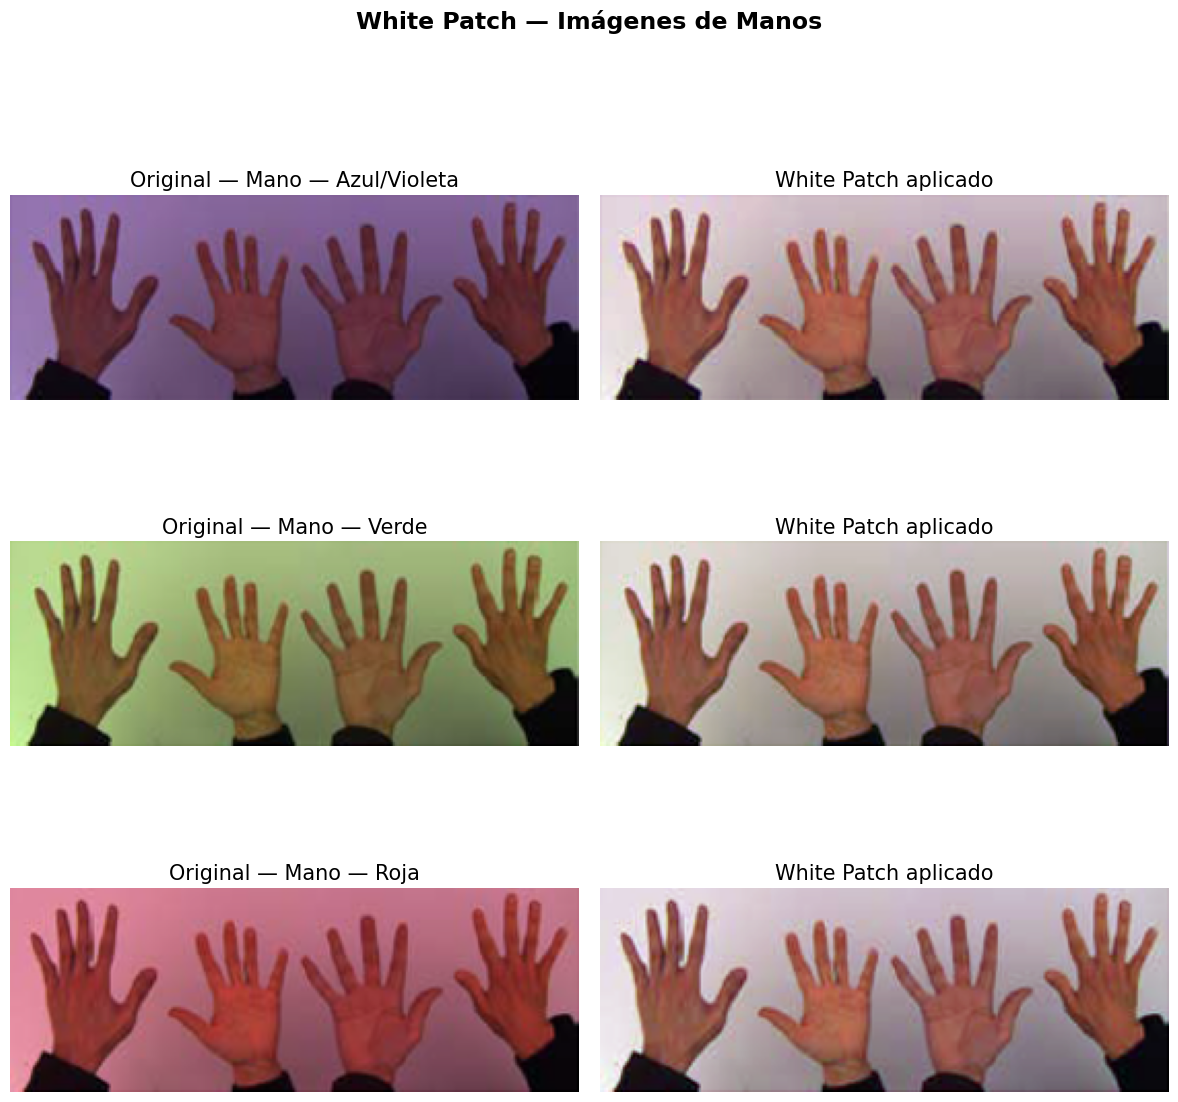

In [3]:
hand_labels = ["Mano — Azul/Violeta", "Mano — Verde", "Mano — Roja"]

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle("White Patch — Imágenes de Manos", fontsize=17, fontweight='bold', y=1.01)

for i, label in enumerate(hand_labels):
    orig = images[label]
    wp   = white_patch(orig)

    axes[i, 0].imshow(orig)
    axes[i, 0].set_title(f"Original — {label}", fontsize=15)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(wp)
    axes[i, 1].set_title("White Patch aplicado", fontsize=15)
    axes[i, 1].axis('off')

plt.tight_layout(pad=1.5)
plt.show()

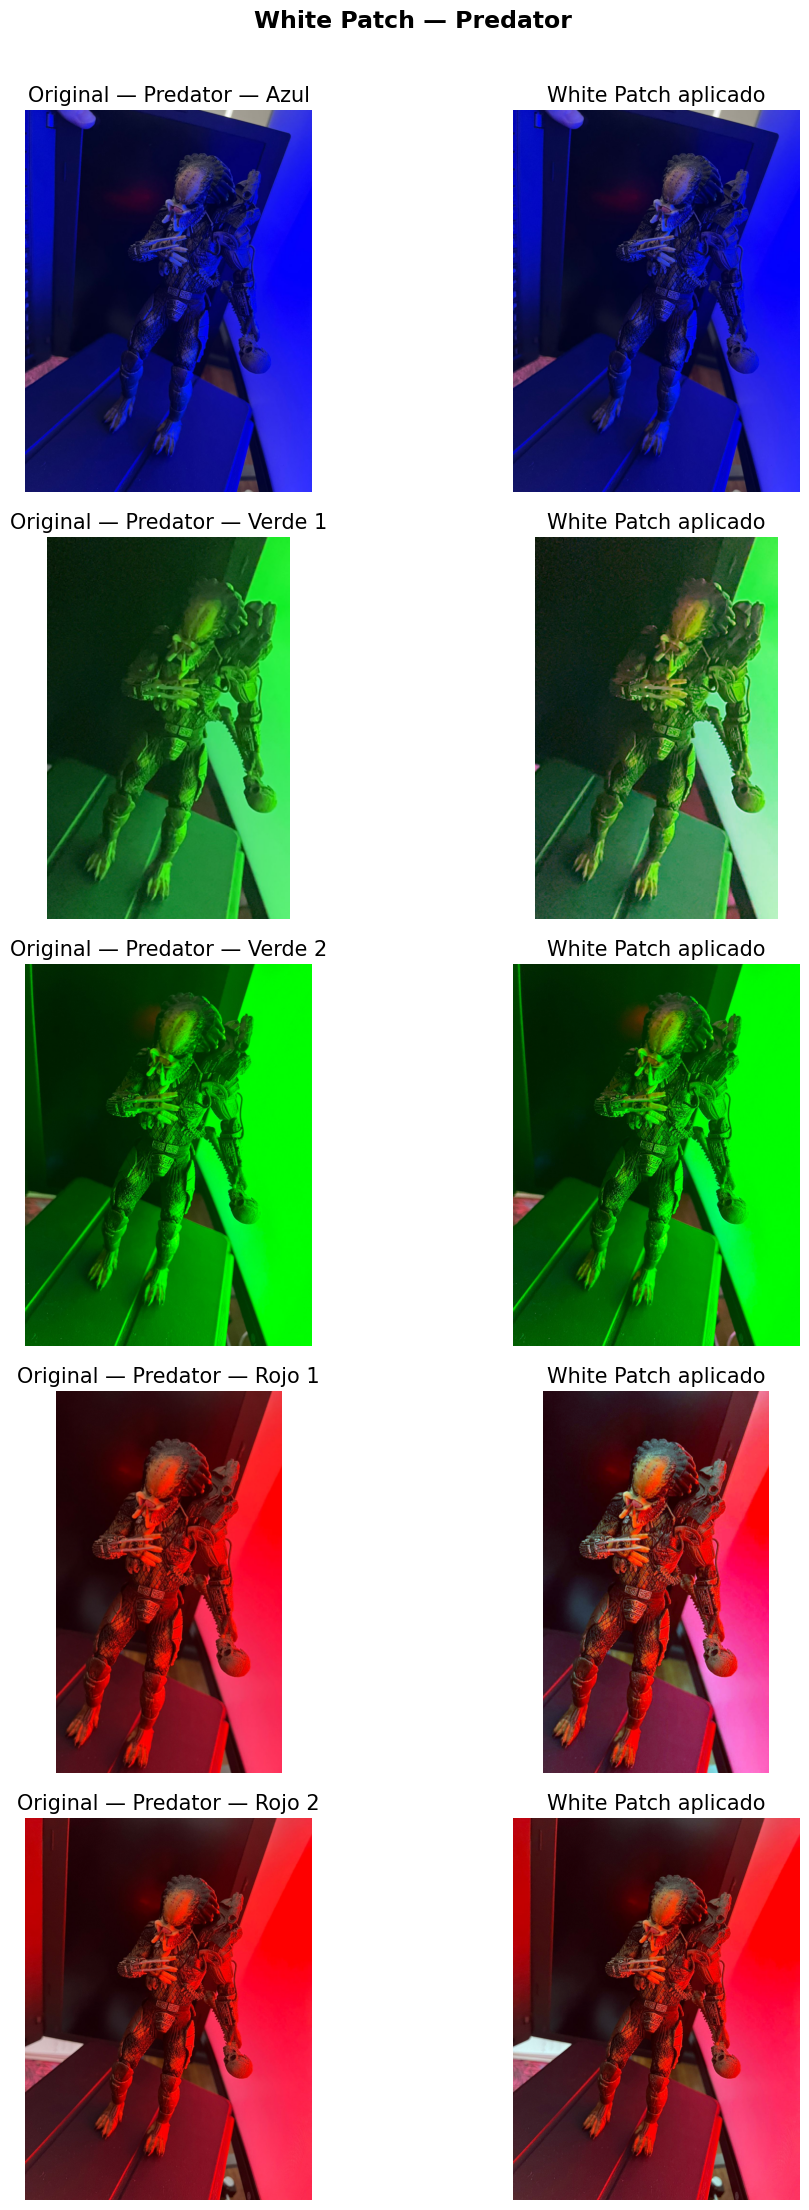

In [4]:
pred_labels = [
    "Predator — Azul",
    "Predator — Verde 1", "Predator — Verde 2",
    "Predator — Rojo 1",  "Predator — Rojo 2",
]

fig, axes = plt.subplots(5, 2, figsize=(12, 22))
fig.suptitle("White Patch — Predator", fontsize=17, fontweight='bold', y=1.005)

for i, label in enumerate(pred_labels):
    orig = images[label]
    wp   = white_patch(orig)

    axes[i, 0].imshow(orig)
    axes[i, 0].set_title(f"Original — {label}", fontsize=15)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(wp)
    axes[i, 1].set_title("White Patch aplicado", fontsize=15)
    axes[i, 1].axis('off')

plt.tight_layout(pad=1.5)
plt.show()

### Conclusiones, análisis y fallas
Antes de avanzar en el análisis vale la pena ver el comportamiento de los valores máximos y promedios de píxeles en cada canal antes y despues de aplicar White Patch, ya que guardan correlación con lo que se puede observar en las imágenes

In [5]:
ch_names  = ['R', 'G', 'B']
print(f"{'Imagen':<28s}  {'Canal':>5}  {'Max orig':>8}  {'Max WP':>6}  {'Media orig':>10}  {'Media WP':>8}")
print("-" * 75)

for label, orig in images.items():
    wp = white_patch(orig)
    for c, cname in enumerate(ch_names):
        mo = orig[:, :, c].max()
        mw = wp[:, :, c].max()
        ao = orig[:, :, c].mean()
        aw = wp[:, :, c].mean()
        lbl = label if c == 0 else ""
        print(f"{lbl:<28s}  {cname:>5}  {mo:>8}  {mw:>6}  {ao:>10.1f}  {aw:>8.1f}")

Imagen                        Canal  Max orig  Max WP  Media orig  Media WP
---------------------------------------------------------------------------
Mano — Azul/Violeta               R       165     255       103.0     158.8
                                  G       138     255        69.5     127.9
                                  B       200     255       100.7     127.9
Mano — Verde                      R       210     255       129.4     156.6
                                  G       250     255       131.1     133.2
                                  B       171     255        83.6     124.1
Mano — Roja                       R       247     255       155.8     160.4
                                  G       157     255        81.1     131.2
                                  B       175     255        91.2     132.4
Predator — Azul                   R       255     255        17.6      17.6
                                  G       255     255        17.1      17.1
            

El algoritmo White Patch asume que el píxel más brillante de la imagen corresponde a una superficie blanca bajo iluminación neutra. Cuando la imagen contiene una región de píxeles blancos, los máximos de cada canal quedan fijados en 255, lo que anula el escalamiento y elimina cualquier corrección de color.

Esto explica la diferencia de rendimiento observada entre las dos versiones de la imagen Predator en verde y rojo, la inclusión del recuadro blanco en la esquina inferior izquierda eleva artificialmente los máximos de todos los canales, impidiendo una normalización uniforme, esto puede verse reflejado directamente en los valores numéricos.
Vemos que para el Predator Verde 2 se elevan los valores de R y B de 126 y 155 a 170 y 172, lo que hace que el valor promedio al aplicar WP incremente en menor medida que en Predator Verde 1.
De igual manera, vemos que para el Predator Rojo 2 se elevan los valores G y B de 134 y 122 a 201 y 203 y el valor promedio incrementa en menor medida.

Para el caso del Predator Azul, los valores máximos ya toman el valor máximo posible por lo que el algoritmo no afecta a la imagen de ninguna manera.

Por último, para el caso de las manos, la iluminación afecta de manera uniforme a todos los píxeles por lo que el algoritmo permite una corrección efectiva.

En resumen, el algoritmo White Patch ofrece buenos resultados bajo una iluminación uniforme donde ningún canal está saturado, pero su desempeño se degrada significativamente cuando la imagen contiene regiones de alta luminosidad que elevan artificialmente los máximos de canal, impidiendo una normalización efectiva. Estos casos son muy comunes, especialmente en imagenes oscuras con reflejos lo que hace que el algoritmo no performe de buena manera.

### Parte 2
1. Para las imágenes img1_tp.png y img2_tp.png leerlas con OpenCV en escala de grisas y visualizarlas.
2. Elija el numero de bins que crea conveniente y grafique su histograma, compare los histogramas entre si. Explicar lo que se observa, si tuviera que entrenar un modelo de clasificación/detección de imágenes, considera que puede ser de utilidad tomar como ‘features’ a los histogramas?

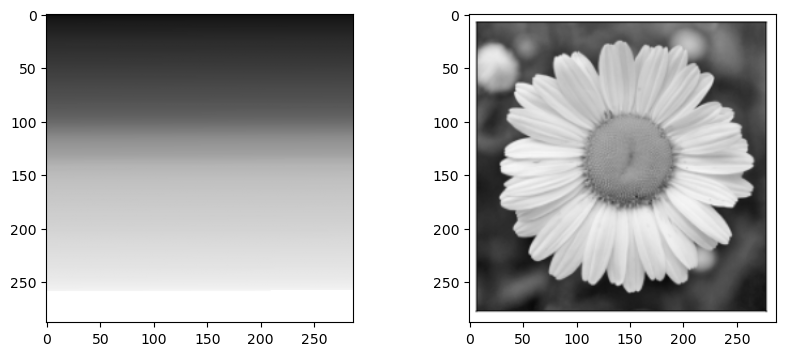

In [6]:
img1 = cv.imread('img1_tp.png', cv.IMREAD_GRAYSCALE)
img2 = cv.imread('img2_tp.png', cv.IMREAD_GRAYSCALE)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img1, cmap='gray')

plt.subplot(1, 2, 2)
plt.imshow(img2, cmap='gray')
plt.show()

## Elección del número de bins

El histograma discretiza el rango de intensidades [0, 255] en bins de igual ancho.
La elección afecta el equilibrio entre detalle y generalización:

| Bins | Ancho de bin | Efecto |
|-----:|:------------:|--------|
| 8    | 32 niveles   | Muy grueso y pierde formas de distribución |
| 16   | 16 niveles   | Útil para visión general |
| 32   | 8 niveles    | Buen compromiso |
| 64   | 4 niveles    | Buena resolución, algo sensible al ruido |
| 256  | 1 nivel      | Máximo detalle, muy sensible a variaciones de iluminación |

Elegimos 32 bins porque es el valor de bins que mejor muestra la forma de la distribución sin agregar un bin que resalta de sobremanera para el valor de 256. En resumen, captura la forma de la distribución sin sobrefitear al ruido de muestreo.

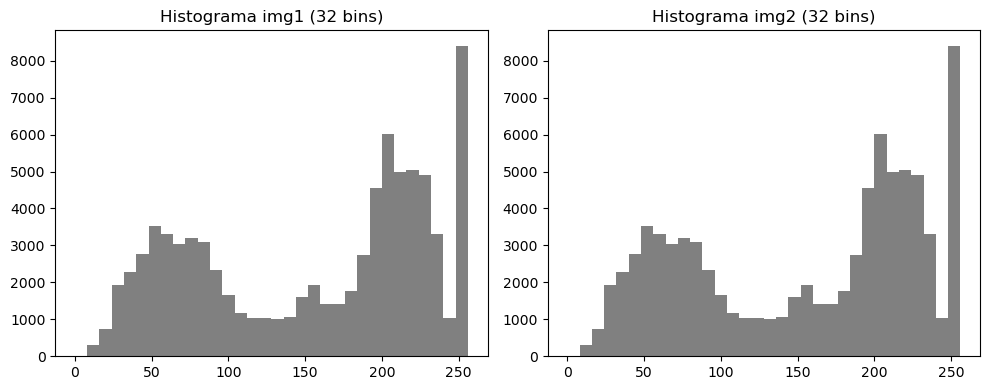

In [7]:
bins = 32

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
hist1, _, _ = plt.hist(img1.ravel(), bins=bins, range=(0, 256), color='gray')
plt.title(f'Histograma img1 ({bins} bins)')

plt.subplot(1, 2, 2)
hist2, _, _ = plt.hist(img2.ravel(), bins=bins, range=(0, 256), color='gray')
plt.title(f'Histograma img2 ({bins} bins)')

plt.tight_layout()
plt.show()

Histogramas idénticos (array_equal): True
Diferencia máxima absoluta: 0.0


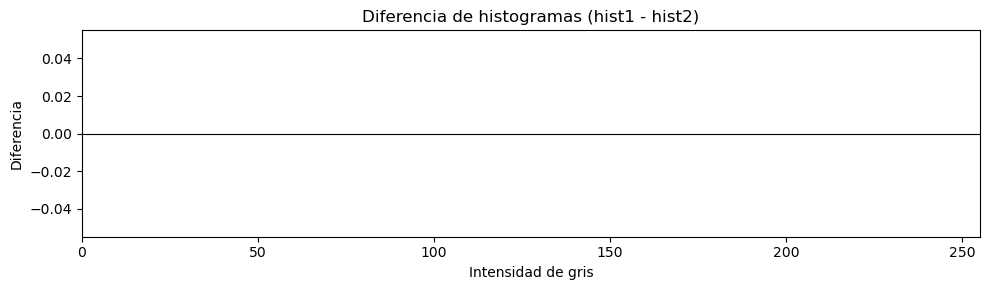

In [8]:
# Verificación numérica de los histogramas
hist_diff = hist1 - hist2
print("Histogramas idénticos (array_equal):", np.array_equal(hist1, hist2))
print("Diferencia máxima absoluta:", np.max(np.abs(hist_diff)))

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(bins), hist_diff, width=1.0, color="crimson", alpha=0.85)
ax.set_title("Diferencia de histogramas (hist1 - hist2)")
ax.set_xlabel("Intensidad de gris")
ax.set_ylabel("Diferencia")
ax.set_xlim(0, 255)
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

### Explicación

Los histogramas en escala de grises de ambas imágenes resultan idénticos pese a que las imágenes son distintas. La verificación numerica confima que ambas imagenes comparten exactamente el mismo conjunto de intensidades. Esto ocurre porque el histograma solo cuenta cuántos pixeles hay de cada nivel de gris, pero no tiene en cuenta dónde está cada píxel en la imagen. Es decir, descarta por completo la informacion espacial (forma, bordes, texturas, etc.).

En conclusión, dos imágenes con contenido semántico radicalmente diferente pueden producir el mismo vector de features, lo que los vuelve indistinguibles para cualquier clasificador que dependa únicamente del histograma.

Los histogramas puede ser utiles como features complementarias, no como descriptor principal, en tareas donde la distribución global de intensidades o color aporta información relevante.

Como alternativa se pueden utilizar histogramas locales por región para recuperar algo de contexto espacial, o utilizar features aprendidas con redes neuronales convolucionales.